In [1]:
import numpy as np
import healpy as hp
import matplotlib.pylab as plt
%matplotlib inline
import sqlite3
import pandas as pd

In [2]:
con = sqlite3.connect("cloud_no_dodge_v5.3.7_1yrs.db")
no_dodge = pd.read_sql("select * from observations;", con)
con.close()

In [3]:
con = sqlite3.connect("cloud_dodge_v5.3.7_1yrs.db")
dodge = pd.read_sql("select * from observations;", con)
con.close()

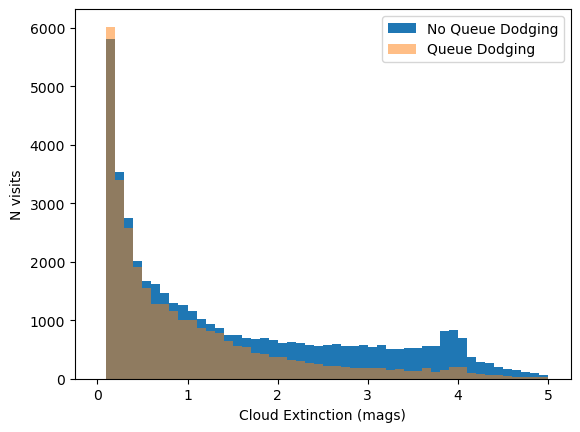

In [18]:
bins=np.arange(51)/50 * 5

good = np.where(no_dodge["cloud_extinction"] > 0.1)[0]
_temp = plt.hist(no_dodge["cloud_extinction"].values[good], bins=bins, label="No Queue Dodging")

good = np.where(dodge["cloud_extinction"] > 0.1)[0]

_temp = plt.hist(dodge["cloud_extinction"][good], bins=bins, alpha=0.5, label="Queue Dodging")

plt.ylabel("N visits")
plt.xlabel("Cloud Extinction (mags)")

leg = plt.legend()